In [1]:
import os
import zipfile
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [15]:
import zipfile
import os

os.makedirs("tea_dataset_raw", exist_ok=True)

files = [
    ("Datasets/algal_leaf.zip", "algal_leaf"),
    ("Datasets/brown_blight.zip", "brown_blight"),
    ("Datasets/white_spot.zip", "white_spot")
]

for zip_path, folder_name in files:
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(f"tea_dataset_raw/{folder_name}")
    else:
        print(f"File not found: {zip_path}")

print("Extraction completed.")

Extraction completed.


In [16]:
for folder in os.listdir("tea_dataset_raw"):
    folder_path = os.path.join("tea_dataset_raw", folder)
    if os.path.isdir(folder_path):
        print(folder, "->", len(os.listdir(folder_path)), "files")

algal_leaf -> 1 files
brown_blight -> 1 files
white_spot -> 1 files


In [17]:
base_path = "tea_dataset_raw"

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        print(folder, "->", len(os.listdir(folder_path)), "images")

algal_leaf -> 1 images
brown_blight -> 1 images
white_spot -> 1 images


In [18]:
base_path = "tea_dataset_raw"

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)

    # Check if there's only one inner folder
    inner_items = os.listdir(cls_path)

    if len(inner_items) == 1:
        inner_folder = os.path.join(cls_path, inner_items[0])

        if os.path.isdir(inner_folder):
            for file in os.listdir(inner_folder):
                shutil.move(
                    os.path.join(inner_folder, file),
                    os.path.join(cls_path, file)
                )

            # Remove empty inner folder
            os.rmdir(inner_folder)

print("Fix completed ✅")

Fix completed ✅


In [19]:
for folder in os.listdir("tea_dataset_raw"):
    folder_path = os.path.join("tea_dataset_raw", folder)
    print(folder, "->", len(os.listdir(folder_path)), "images")

algal_leaf -> 113 images
brown_blight -> 113 images
white_spot -> 142 images


In [20]:
source_dir = "tea_dataset_raw"
base_dir = "tea_dataset_split"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Create folders
for split in [train_dir, val_dir, test_dir]:
    os.makedirs(split, exist_ok=True)

classes = os.listdir(source_dir)

for cls in classes:
    cls_path = os.path.join(source_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_split = int(0.7 * total)
    val_split = int(0.15 * total)

    train_imgs = images[:train_split]
    val_imgs = images[train_split:train_split + val_split]
    test_imgs = images[train_split + val_split:]

    for split_name, split_imgs in zip(
        [train_dir, val_dir, test_dir],
        [train_imgs, val_imgs, test_imgs]
    ):
        split_cls_path = os.path.join(split_name, cls)
        os.makedirs(split_cls_path, exist_ok=True)

        for img in split_imgs:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(split_cls_path, img)
            )

print("✅ Dataset split completed")

✅ Dataset split completed


In [21]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} SET")
    split_path = os.path.join(base_dir, split)

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        print(cls, "->", len(os.listdir(cls_path)))


TRAIN SET
algal_leaf -> 79
brown_blight -> 79
white_spot -> 99

VAL SET
algal_leaf -> 16
brown_blight -> 16
white_spot -> 21

TEST SET
algal_leaf -> 18
brown_blight -> 18
white_spot -> 22


In [22]:
img_size = (224, 224)
batch_size = 16

# Training (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 257 images belonging to 3 classes.
Found 53 images belonging to 3 classes.
Found 58 images belonging to 3 classes.


VGG16 Model

In [23]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model_vgg = Model(inputs=base_model.input, outputs=output)

model_vgg.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 403s 7us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_vgg16_model.keras",
    monitor='val_loss',
    save_best_only=True
)

history_vgg = model_vgg.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.3268 - loss: 1.2902 - val_accuracy: 0.3019 - val_loss: 1.1161
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.3696 - loss: 1.2110 - val_accuracy: 0.3962 - val_loss: 1.0727
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.3541 - loss: 1.1853 - val_accuracy: 0.3962 - val_loss: 1.0623
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.3774 - loss: 1.1547 - val_accuracy: 0.4528 - val_loss: 1.0570
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.3774 - loss: 1.1662 - val_accuracy: 0.4717 - val_loss: 1.0509
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4436 - loss: 1.0692 - val_accuracy: 0.4340 - val_loss: 1.0443
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.4436 - loss: 1.0744 - val_accuracy: 0.4340 - val_loss: 1.0389
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.3852 - loss: 1.1633 - val_accuracy: 0.4340 - val_loss:

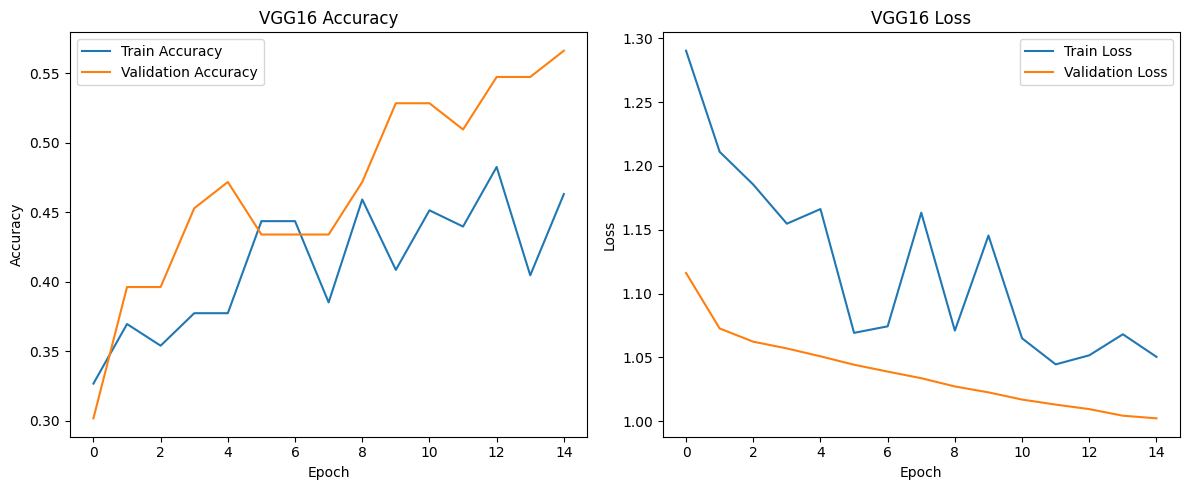

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_generator)

print("VGG16 Test Loss:", test_loss_vgg)
print("VGG16 Test Accuracy:", test_acc_vgg)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5517 - loss: 0.9993
VGG16 Test Loss: 0.9993290901184082
VGG16 Test Accuracy: 0.5517241358757019


4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step


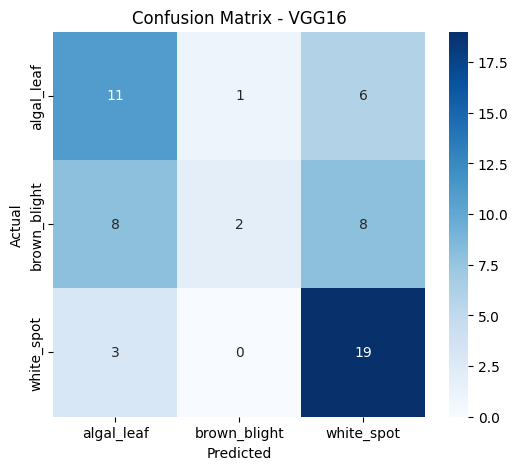

              precision    recall  f1-score   support

  algal_leaf       0.50      0.61      0.55        18
brown_blight       0.67      0.11      0.19        18
  white_spot       0.58      0.86      0.69        22

    accuracy                           0.55        58
   macro avg       0.58      0.53      0.48        58
weighted avg       0.58      0.55      0.49        58



In [27]:
y_pred = model_vgg.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - VGG16")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

ResNet50 Model

In [28]:
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model_resnet.layers:
    layer.trainable = False

x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model_resnet = Model(inputs=base_model_resnet.input, outputs=output)

model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1766s 19us/step
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2802 - loss: 1.3923 - val_accuracy: 0.3208 - val_loss: 1.1221
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 846ms/step - accuracy: 0.3969 - loss: 1.2396 - val_accuracy: 0.3962 - val_loss: 1.0954
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 806ms/step - accuracy: 0.3346 - loss: 1.1780 - val_accuracy: 0.3962 - val_loss: 1.0951
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 789ms/step - accuracy: 0.2879 - loss: 1.2792 - val_accuracy: 0.4151 - val_loss: 1.0959
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 784ms/step - accuracy: 0.2840 - loss: 1.2103 - val_accuracy: 0.3962 - val_loss: 1.0914


In [33]:
model_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,375,691 (92.99 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 525,320 (2.00 MB)

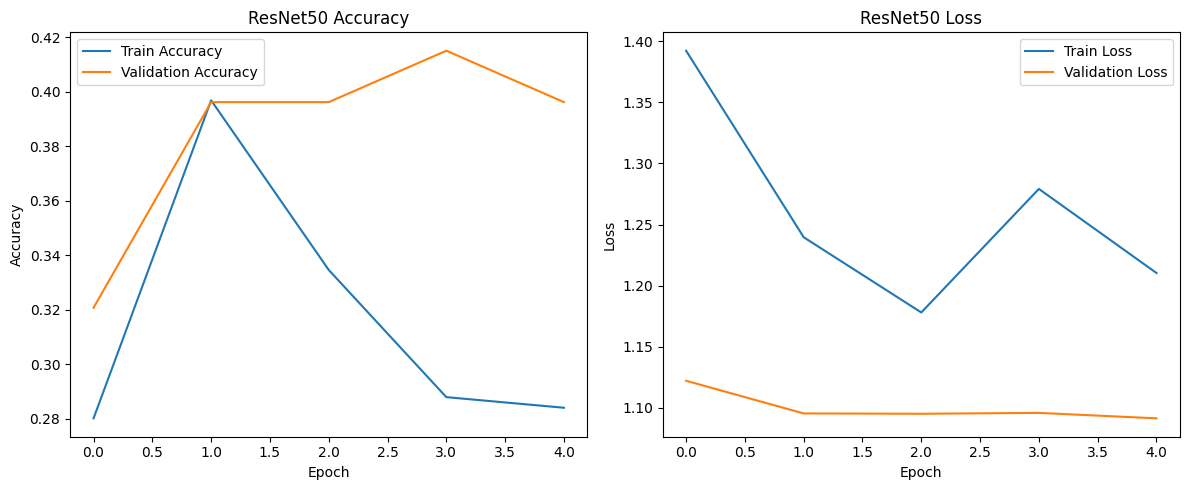

In [32]:


plt.figure(figsize=(12,5))

# ✅ Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ✅ Loss Graph
plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_generator)

print("ResNet50 Test Loss:", test_loss_resnet)
print("ResNet50 Test Accuracy:", test_acc_resnet)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 578ms/step - accuracy: 0.3621 - loss: 1.1220
ResNet50 Test Loss: 1.122023582458496
ResNet50 Test Accuracy: 0.36206895112991333


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  


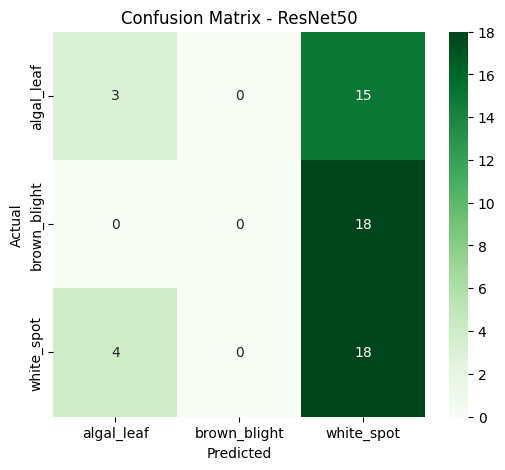

Classification Report - ResNet50

              precision    recall  f1-score   support

  algal_leaf       0.43      0.17      0.24        18
brown_blight       0.00      0.00      0.00        18
  white_spot       0.35      0.82      0.49        22

    accuracy                           0.36        58
   macro avg       0.26      0.33      0.24        58
weighted avg       0.27      0.36      0.26        58



C:\Users\Ahamed Samhan Fazeel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ahamed Samhan Fazeel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ahamed Samhan Fazeel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python31

In [30]:


# Predict on test data
y_pred_resnet = model_resnet.predict(test_generator)

# Convert probabilities → class labels
y_pred_classes_resnet = np.argmax(y_pred_resnet, axis=1)

# True labels
y_true_resnet = test_generator.classes

# Class names
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm_resnet = confusion_matrix(y_true_resnet, y_pred_classes_resnet)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix - ResNet50")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report - ResNet50\n")
print(classification_report(y_true_resnet, y_pred_classes_resnet, target_names=class_labels))

Compare Both Model

In [31]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["VGG16", "ResNet50"],
    "Test Accuracy": [test_acc_vgg, test_acc_resnet],
    "Test Loss": [test_loss_vgg, test_loss_resnet]
})

print(comparison)

      Model  Test Accuracy  Test Loss
0     VGG16       0.551724   0.999329
1  ResNet50       0.362069   1.122024
